# Documentação do Programa de Análise de Regressão
### Introdução
#### Este programa foi desenvolvido para facilitar a análise de regressão de dados de entrada em formato CSV. Ele permite carregar dados de um arquivo CSV, calcular a linha de regressão e plotar um gráfico para visualizar os dados originais juntamente com a linha de regressão.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Variáveis globais para armazenar os tempos de execução e os tamanhos de entrada
execution_times = []
input_sizes = []

In [3]:
# Função para ler os dados de um arquivo CSV.
def read_from_file():
    global execution_times, input_sizes
    filename = input("Enter the data file name with the data (.csv): ")
    try:
        # Leitura dos dados do arquivo CSV usando o Pandas
        data = pd.read_csv(filename, delimiter=";")
        # Conversão dos dados para o tipo float e armazenamento nas variáveis globais
        input_sizes = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).tolist()
        execution_times = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).tolist()
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("File not found. Please check the filename and try again.")
    except Exception as e:
        print(f"An error occurred: {e}")


In [4]:

def calculate_regression_line():
    """
    Função para calcular a linha de regressão.

    Calcula a linha de regressão dos dados de entrada usando a função linregress do módulo stats do Scipy.
    """
    global model
    # Calcula a linha de regressão usando os dados de entrada e de execução
    model = stats.linregress(input_sizes, execution_times)
    # Chama a função para plotar o gráfico
    plot_graph()

In [5]:

def plot_graph():
    """
    Função para plotar o gráfico dos dados originais e da linha de regressão.

    Plota um gráfico dos dados originais (tamanhos de entrada versus tempos de execução) e da linha de regressão calculada.
    """
    print('#################################################################')
    # Imprime a equação da linha de regressão
    print(f'The regression line is y = {model.intercept:.3f} + {model.slope:.3f}x')
    # Plota o gráfico dos dados originais como pontos
    plt.plot(input_sizes, execution_times, 'o', label='Original data')
    # Plota a linha de regressão
    plt.plot(input_sizes, model.intercept + model.slope * pd.Series(input_sizes), 'r', label='Regression Line')
    # Adiciona legendas aos eixos e ao gráfico
    plt.legend()
    plt.xlabel('Input Size')
    plt.ylabel('Execution Time')
    plt.title('Execution Time vs. Input Size')
    # Exibe o gráfico
    plt.show()

In [6]:

# Função para ajustar a regressão polinomial
def polyfit(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    p = np.poly1d(coeffs)
    return p


In [7]:

# Função para encontrar o melhor grau do polinómio
def find_best_degree(x, y, max_degree):
    r2_values = []
    degrees = list(range(1, max_degree + 1))
    best_r2 = -np.inf
    best_degree = 1
    best_p = None
    
    for degree in degrees:
        p = polyfit(x, y, degree)
        y_pred = p(x)
        y_mean = np.mean(y)
        ss_tot = np.sum((y - y_mean) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        r2_values.append(r2)
        
        if r2 > best_r2:
            best_r2 = r2
            best_degree = degree
            best_p = p

    # Identificar possível overfitting analisando a diferença entre R² consecutivos
    for i in range(1, len(r2_values)):
        if r2_values[i] - r2_values[i-1] < 0.01:  # Marginal improvement threshold
            best_degree = degrees[i-1]
            best_p = polyfit(x, y, best_degree)
            best_r2 = r2_values[i-1]
            break

    return best_degree, best_p, best_r2

In [8]:

def calculate_polynomial_regression():
    """
    Função para calcular a regressão polinomial.
    """
    max_degree = 15
    best_degree, best_p, best_r2 = find_best_degree(input_sizes, execution_times, max_degree)
    
    print(f'Melhor grau do polinómio: {best_degree}')
    print(f'Coeficientes da regressão polinomial: {best_p}')
    print(f'O coeficiente de determinação (R²) é: {best_r2:.3f}')
    
    # Gerar previsões com o melhor polinómio
    y_pred = best_p(input_sizes)
    
    # Plot dos dados e da linha de regressão polinomial
    plt.scatter(input_sizes, execution_times, color='blue', label='Dados originais')
    plt.plot(input_sizes, y_pred, color='red', label='Regressão polinomial')
    plt.xlabel('Size')
    plt.ylabel('Time')
    plt.title('Ajuste da Regressão Polinomial')
    plt.legend()
    plt.show()

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression (Data Loaded)
3 --- Show Polynomial Regression (Data Loaded)
0 --- Exit
Invalid input. Please enter a number.
-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression (Data Loaded)
3 --- Show Polynomial Regression (Data Loaded)
0 --- Exit
Data loaded successfully.
-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
Melhor grau do polinómio: 2
Coeficientes da regressão polinomial:            2
0.0001251 x - 0.1375 x + 85.49
O coeficiente de determinação (R²) é: 0.977


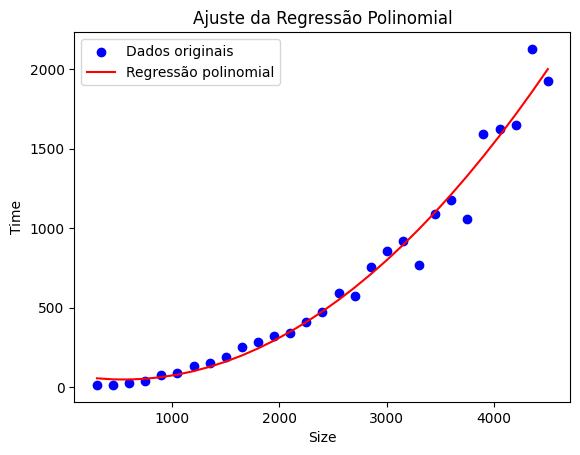

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
#################################################################
The regression line is y = -438.092 + 0.463x


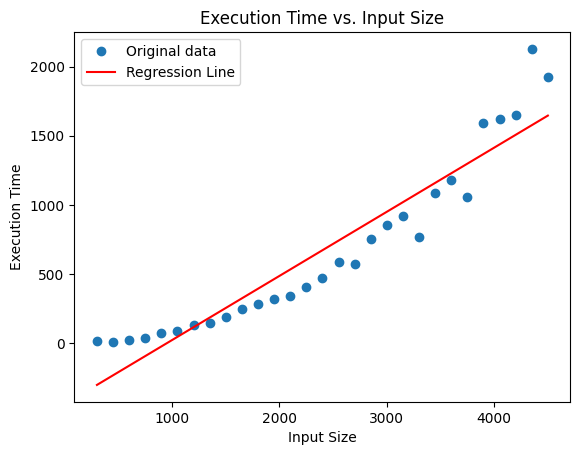

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Linear Regression
3 --- Show Polynomial Regression
0 --- Exit
Exiting...


In [9]:

# Loop principal do programa
option = -1
while option != 0:
    print("-------MAIN MENU---------")
    print("Select an option:")
    print("1 --- Introduce File Name")
    if execution_times:
        print("2 --- Show Linear Regression")
        print("3 --- Show Polynomial Regression")
    else:
        print("2 --- Show Linear Regression (Data Loaded)")
        print("3 --- Show Polynomial Regression (Data Loaded)")
    print("0 --- Exit")
    try:
        option = int(input("opt: "))
        if option == 1:
            read_from_file()  # Chama a função para ler os dados do arquivo CSV
        elif option == 2:
            if input_sizes and execution_times:
                calculate_regression_line()  # Chama a função para calcular a linha de regressão
            else:
                print("Please load data first by selecting option 1.")
        elif option == 3:
            if input_sizes and execution_times:
                calculate_polynomial_regression()  # Chama a função para calcular a regressão polinomial
            else:
                print("Please load data first by selecting option 1.")
        elif option == 0:
            print("Exiting...")
        else:
            print("Invalid option. Please select a valid option.")
    except ValueError:
        print("Invalid input. Please enter a number.")